# Compare Water Masks: CBERS-4 (Namikawa) vs Sentinel-2 (SCL)

### What this notebook does

1. Define a small comparison ROI (e.g., 30×30 km around a reservoir)
2. Clip **both** water masks to that exact ROI
3. Reproject Sentinel-2 SCL mask to the CBERS-4 grid (64 m)
4. Side-by-side visual comparison
5. Pixel-level agreement analysis and accuracy metrics

---
## 0. Imports

In [16]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds as transform_from_bounds
from pyproj import Transformer
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10

print("Imports OK.")

Imports OK.


---
## 1. Configuration — EDIT THIS SECTION

In [17]:
# =====================================================================
#  >>> EDIT THESE PATHS <<<
# =====================================================================

# CBERS-4 Namikawa water mask (from namikawa_first_test.ipynb)
CBERS4_MASK_PATH = "C:/Users/xavie/cipc-data/output/cbers-4/water_mask.tif"

# Sentinel-2 water masks (from sentinel2_water_mask.ipynb)
S2_SCL_MASK_PATH   = "C:/Users/xavie/cipc-data/output/sentinel-2/s2_scl_water_20260208.tif"
#S2_MNDWI_MASK_PATH = "C:/Users/xavie/cipc-data/output/sentinel-2/s2_mndwi_water_20260208.tif"

# Output directory
OUTPUT_DIR = "C:/Users/xavie/cipc-data/output/comp"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify files exist
for label, path in [("CBERS-4", CBERS4_MASK_PATH),
                     ("S2 SCL", S2_SCL_MASK_PATH),
                     ("S2 MNDWI", S2_MNDWI_MASK_PATH)]:
    exists = os.path.exists(path)
    print(f"  {label:10s}: {'OK' if exists else 'NOT FOUND'}  → {path}")

  CBERS-4   : OK  → C:/Users/xavie/cipc-data/output/cbers-4/water_mask.tif
  S2 SCL    : OK  → C:/Users/xavie/cipc-data/output/sentinel-2/s2_scl_water_20260208.tif
  S2 MNDWI  : OK  → C:/Users/xavie/cipc-data/output/sentinel-2/s2_mndwi_water_20260208.tif


### 1.2 Comparison ROI

Define a focused bounding box in **EPSG:4326** (lat/lon).  
Choose a small area (e.g., 20–50 km) that contains water features visible in both datasets.

**Tip:** Open your CBERS-4 false-color composite in QGIS, find an interesting reservoir or river stretch, and copy the coordinates.

In [18]:
# =====================================================================
#  >>> DEFINE YOUR COMPARISON ROI [west, south, east, north] <<<
# =====================================================================

COMPARE_BBOX = [
    -54.6300, # Oeste 
    -25.6500, # Sul 
    -54.4300, # Leste 
    -25.4200  # Norte
]

# Target resolution for comparison (meters)
TARGET_RES = 64  # CBERS-4 WFI resolution

west, south, east, north = COMPARE_BBOX
width_km = (east - west) * 111 * np.cos(np.radians((south + north) / 2))
height_km = (north - south) * 111
print(f"Comparison ROI: {COMPARE_BBOX}")
print(f"Approximate size: {width_km:.0f} × {height_km:.0f} km")
print(f"Target resolution: {TARGET_RES} m")

Comparison ROI: [-54.63, -25.65, -54.43, -25.42]
Approximate size: 20 × 26 km
Target resolution: 64 m


---
## 2. Inspect Source Files

In [19]:
def describe_raster(path, label):
    """Print key metadata of a raster file."""
    with rasterio.open(path) as src:
        res_x, res_y = src.res
        tr = Transformer.from_crs(src.crs, "EPSG:4326", always_xy=True)
        ll = tr.transform(src.bounds.left, src.bounds.bottom)
        ur = tr.transform(src.bounds.right, src.bounds.top)
        print(f"\n{label}")
        print(f"  File:       {path}")
        print(f"  Shape:      {src.height} × {src.width}")
        print(f"  CRS:        {src.crs}")
        print(f"  Resolution: {res_x:.1f} × {res_y:.1f} m")
        print(f"  Bounds (4326): W={ll[0]:.3f} S={ll[1]:.3f} E={ur[0]:.3f} N={ur[1]:.3f}")
        return src.crs, src.bounds, src.res

cbers_crs, cbers_bounds, cbers_res = describe_raster(CBERS4_MASK_PATH, "CBERS-4 Water Mask")
scl_crs, scl_bounds, scl_res       = describe_raster(S2_SCL_MASK_PATH, "Sentinel-2 SCL Water Mask")


CBERS-4 Water Mask
  File:       C:/Users/xavie/cipc-data/output/cbers-4/water_mask.tif
  Shape:      14013 × 16342
  CRS:        EPSG:32722
  Resolution: 64.0 × 64.0 m
  Bounds (4326): W=-58.816 S=-29.645 E=-48.214 N=-21.755

Sentinel-2 SCL Water Mask
  File:       C:/Users/xavie/cipc-data/output/sentinel-2/s2_scl_water_20260208.tif
  Shape:      1256 × 1029
  CRS:        EPSG:32721
  Resolution: 20.0 × 20.0 m
  Bounds (4326): W=-54.630 S=-25.650 E=-54.430 N=-25.420


---
## 3. Helper: Clip and Reproject to Common Grid

In [20]:
def clip_and_reproject(src_path, bbox_4326, target_crs, target_res,
                       resampling=Resampling.nearest):
    """
    Clip a raster to a BBOX and reproject to a target CRS/resolution.
    """
    west, south, east, north = bbox_4326
    
    tr = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
    t_left, t_bottom = tr.transform(west, south)
    t_right, t_top = tr.transform(east, north)
    
    out_width = int(np.ceil((t_right - t_left) / target_res))
    out_height = int(np.ceil((t_top - t_bottom) / target_res))
    
    out_transform = transform_from_bounds(
        t_left, t_bottom, t_right, t_top, out_width, out_height
    )
    
    dst_data = np.zeros((out_height, out_width), dtype=np.uint8)
    
    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=dst_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=out_transform,
            dst_crs=target_crs,
            dst_nodata=255,
            resampling=resampling,
        )
    
    out_profile = {
        'driver': 'GTiff',
        'dtype': 'uint8',
        'width': out_width,
        'height': out_height,
        'count': 1,
        'crs': target_crs,
        'transform': out_transform,
        'nodata': 255,
    }
    
    return dst_data, out_profile

print("Helper function defined.")

Helper function defined.


---
## 4. Clip Both Masks to the Comparison ROI

In [21]:
TARGET_CRS = cbers_crs
print(f"Target CRS: {TARGET_CRS}")
print(f"Target resolution: {TARGET_RES} m")
print()

print("Clipping CBERS-4 Namikawa mask...")
cbers_clip, cbers_clip_profile = clip_and_reproject(
    CBERS4_MASK_PATH, COMPARE_BBOX, TARGET_CRS, TARGET_RES
)
print(f"  Output shape: {cbers_clip.shape}")

print("Clipping Sentinel-2 SCL mask...")
scl_clip, scl_clip_profile = clip_and_reproject(
    S2_SCL_MASK_PATH, COMPARE_BBOX, TARGET_CRS, TARGET_RES
)
print(f"  Output shape: {scl_clip.shape}")

# Align shapes (handle off-by-one from rounding)
min_h = min(cbers_clip.shape[0], scl_clip.shape[0])
min_w = min(cbers_clip.shape[1], scl_clip.shape[1])
cbers_clip = cbers_clip[:min_h, :min_w]
scl_clip   = scl_clip[:min_h, :min_w]
print(f"\nFinal aligned shape: {min_h} × {min_w}")

Target CRS: EPSG:32722
Target resolution: 64 m

Clipping CBERS-4 Namikawa mask...
  Output shape: (407, 304)
Clipping Sentinel-2 SCL mask...
  Output shape: (407, 304)

Final aligned shape: 407 × 304


---
## 5. Convert to Binary Water Masks

In [22]:
# CBERS-4: codes 1–4 are water (different confidence), 0 = non-water, 255 = nodata
cbers_water = np.where(
    cbers_clip == 255, 255,
    np.where((cbers_clip >= 1) & (cbers_clip <= 4), 1, 0)
).astype(np.uint8)

# Sentinel-2 SCL: 1 = water, 0 = non-water, 255 = nodata
scl_water = np.where(scl_clip == 255, 255, scl_clip).astype(np.uint8)

# Valid mask: pixels valid in BOTH products
valid = (cbers_water != 255) & (scl_water != 255)

print(f"Valid pixels (both products): {valid.sum():,d}")
print(f"\nWater pixel counts (within valid area):")
print(f"  CBERS-4 Namikawa: {(cbers_water[valid] == 1).sum():>10,d}")
print(f"  Sentinel-2 SCL:   {(scl_water[valid] == 1).sum():>10,d}")

Valid pixels (both products): 119,599

Water pixel counts (within valid area):
  CBERS-4 Namikawa:      5,059
  Sentinel-2 SCL:        6,049


---
## 6. Visual Comparison — Side by Side

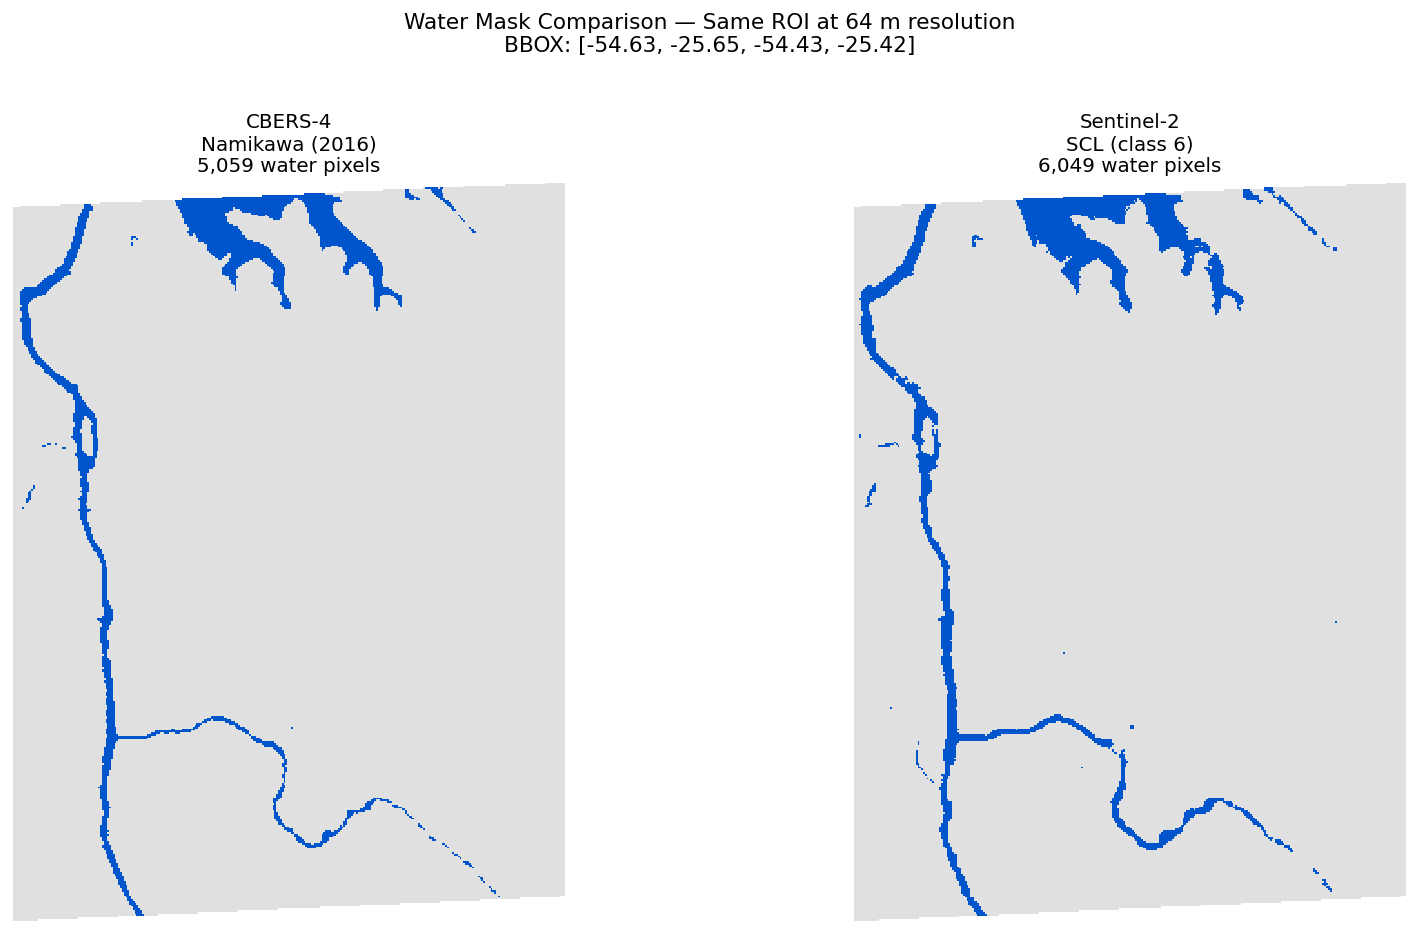

In [23]:
def plot_water_mask(ax, data, title, valid_mask):
    """Plot a binary water mask with consistent styling."""
    display = data.astype(float)
    display[~valid_mask] = np.nan
    cmap = ListedColormap(["#e0e0e0", "#0055cc"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)
    ax.imshow(display, cmap=cmap, norm=norm, interpolation="none")
    n_water = (data[valid_mask] == 1).sum()
    ax.set_title(f"{title}\n{n_water:,d} water pixels", fontsize=11)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_water_mask(axes[0], cbers_water, "CBERS-4\nNamikawa (2016)", valid)
plot_water_mask(axes[1], scl_water, "Sentinel-2\nSCL (class 6)", valid)

fig.suptitle(
    f"Water Mask Comparison — Same ROI at {TARGET_RES} m resolution\n"
    f"BBOX: {COMPARE_BBOX}",
    fontsize=12, y=1.02
)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "01_side_by_side.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Agreement Map

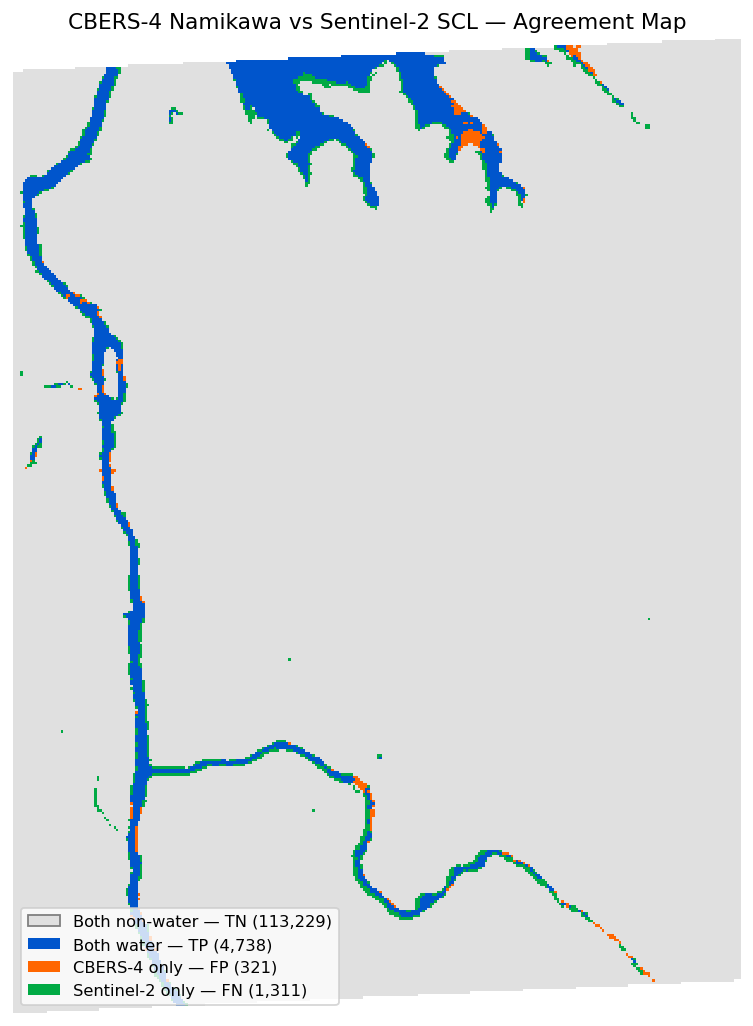

TP (both water):            4,738
FP (CBERS-4 only):            321
FN (Sentinel-2 only):       1,311
TN (both non-water):      113,229


In [24]:
c = (cbers_water == 1) & valid
s = (scl_water == 1) & valid

tp = c & s                    # Both detect water
fp = c & ~s                   # CBERS-4 only
fn = ~c & s                   # SCL only
tn = ~c & ~s & valid          # Both non-water

# Build agreement raster
agree = np.full(cbers_water.shape, np.nan)
agree[tn] = 0
agree[tp] = 1
agree[fp] = 2
agree[fn] = 3

fig, ax = plt.subplots(figsize=(10, 8))
cmap = ListedColormap(["#e0e0e0", "#0055cc", "#ff6600", "#00aa44"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)
ax.imshow(agree, cmap=cmap, norm=norm, interpolation="none")
ax.set_title("CBERS-4 Namikawa vs Sentinel-2 SCL — Agreement Map", fontsize=12)
ax.axis("off")

legend_elements = [
    Patch(facecolor="#e0e0e0", edgecolor="gray", label=f"Both non-water — TN ({tn.sum():,d})"),
    Patch(facecolor="#0055cc", label=f"Both water — TP ({tp.sum():,d})"),
    Patch(facecolor="#ff6600", label=f"CBERS-4 only — FP ({fp.sum():,d})"),
    Patch(facecolor="#00aa44", label=f"Sentinel-2 only — FN ({fn.sum():,d})"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9, frameon=True)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "02_agreement_map.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"TP (both water):       {tp.sum():>10,d}")
print(f"FP (CBERS-4 only):     {fp.sum():>10,d}")
print(f"FN (Sentinel-2 only):  {fn.sum():>10,d}")
print(f"TN (both non-water):   {tn.sum():>10,d}")

---
## 8. Accuracy Metrics

Using Sentinel-2 SCL as the **reference** and CBERS-4 Namikawa as the **test**.

In [25]:
tp_n = tp.sum()
fp_n = fp.sum()
fn_n = fn.sum()
tn_n = tn.sum()
total = tp_n + fp_n + fn_n + tn_n

oa = (tp_n + tn_n) / total if total > 0 else 0
precision = tp_n / (tp_n + fp_n) if (tp_n + fp_n) > 0 else 0
recall = tp_n / (tp_n + fn_n) if (tp_n + fn_n) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

pe = ((tp_n + fp_n) * (tp_n + fn_n) + (fn_n + tn_n) * (fp_n + tn_n)) / (total ** 2) if total > 0 else 0
kappa = (oa - pe) / (1 - pe) if (1 - pe) > 0 else 0

print("=" * 50)
print("CBERS-4 Namikawa vs Sentinel-2 SCL (reference)")
print("=" * 50)
print(f"  Overall Accuracy:     {oa:.4f}  ({oa*100:.2f}%)")
print(f"  Kappa:                {kappa:.4f}")
print(f"  Precision (User's):   {precision:.4f}")
print(f"  Recall (Producer's):  {recall:.4f}")
print(f"  F1-Score:             {f1:.4f}")
print()
print("Interpretation:")
print(f"  Precision = {precision:.2%} of what CBERS-4 calls water is also water in SCL")
print(f"  Recall    = {recall:.2%} of SCL water is captured by CBERS-4")

CBERS-4 Namikawa vs Sentinel-2 SCL (reference)
  Overall Accuracy:     0.9864  (98.64%)
  Kappa:                0.8460
  Precision (User's):   0.9365
  Recall (Producer's):  0.7833
  F1-Score:             0.8531

Interpretation:
  Precision = 93.65% of what CBERS-4 calls water is also water in SCL
  Recall    = 78.33% of SCL water is captured by CBERS-4


---
## 9. Per-Class Breakdown

Check which CBERS-4 confidence classes (WATER, WATER95, WATER90, WATER80)
agree best with Sentinel-2 SCL.

In [26]:
class_names = {1: "WATER", 2: "WATER95", 3: "WATER90", 4: "WATER80"}
scl_ref = (scl_water == 1) & valid

print(f"{'Class':10s}  {'Pixels':>10s}  {'Also in SCL':>12s}  {'Match %':>8s}  {'Not in SCL':>11s}")
print("-" * 60)

for code, name in class_names.items():
    class_mask = (cbers_clip == code) & valid
    n_class = class_mask.sum()
    if n_class == 0:
        print(f"{name:10s}  {0:>10,d}  {'—':>12s}  {'—':>8s}  {'—':>11s}")
        continue
    n_match = (class_mask & scl_ref).sum()
    n_nomatch = n_class - n_match
    pct = 100 * n_match / n_class
    print(f"{name:10s}  {n_class:>10,d}  {n_match:>12,d}  {pct:>7.1f}%  {n_nomatch:>11,d}")

missed = scl_ref & (cbers_water != 1)
print(f"\nWater in SCL but missed by CBERS-4: {missed.sum():,d} pixels")

Class           Pixels   Also in SCL   Match %   Not in SCL
------------------------------------------------------------
WATER                7             5     71.4%            2
WATER95          4,551         4,326     95.1%          225
WATER90            501           407     81.2%           94
WATER80              0             —         —            —

Water in SCL but missed by CBERS-4: 1,311 pixels


---
## 10. Export Clipped Masks

In [27]:
def save_clipped(data, profile, filepath):
    """Save a clipped mask as GeoTIFF."""
    p = profile.copy()
    p.update(dtype='uint8', count=1, nodata=255, compress='lzw',
             height=data.shape[0], width=data.shape[1])
    with rasterio.open(filepath, 'w', **p) as dst:
        dst.write(data, 1)
    print(f"  Saved: {filepath}")

save_clipped(cbers_clip, cbers_clip_profile,
             os.path.join(OUTPUT_DIR, "cbers4_namikawa_clipped.tif"))
save_clipped(scl_clip, scl_clip_profile,
             os.path.join(OUTPUT_DIR, "s2_scl_clipped.tif"))

print(f"\nBoth clipped masks share the same grid:")
print(f"  CRS: {TARGET_CRS}")
print(f"  Resolution: {TARGET_RES} m")
print(f"  Shape: {min_h} × {min_w}")
print(f"  BBOX: {COMPARE_BBOX}")

  Saved: C:/Users/xavie/cipc-data/output/comp\cbers4_namikawa_clipped.tif
  Saved: C:/Users/xavie/cipc-data/output/comp\s2_scl_clipped.tif

Both clipped masks share the same grid:
  CRS: EPSG:32722
  Resolution: 64 m
  Shape: 407 × 304
  BBOX: [-54.63, -25.65, -54.43, -25.42]


---
## 11. Summary

### Outputs

| File | Contents |
|------|----------|
| `01_side_by_side.png` | Both water masks at the same scale |
| `02_agreement_map.png` | TP/FP/FN/TN spatial patterns |
| `cbers4_namikawa_clipped.tif` | CBERS-4 mask clipped to ROI |
| `s2_scl_clipped.tif` | S2 SCL mask clipped and reprojected |

### Interpreting the metrics

- **Low recall** → CBERS-4 misses water that SCL detects → thresholds too narrow
- **Low precision** → CBERS-4 flags non-water as water → commission errors (shadows, urban)
- **WATER class should have highest match %** in the per-class breakdown
- **WATER80 class will likely have lowest match %** — least confident class